In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix



In [3]:
!pip install seaborn


In [4]:
data = pd.read_csv('dataset.csv')
data = data.sample(frac=0.5, random_state=42)

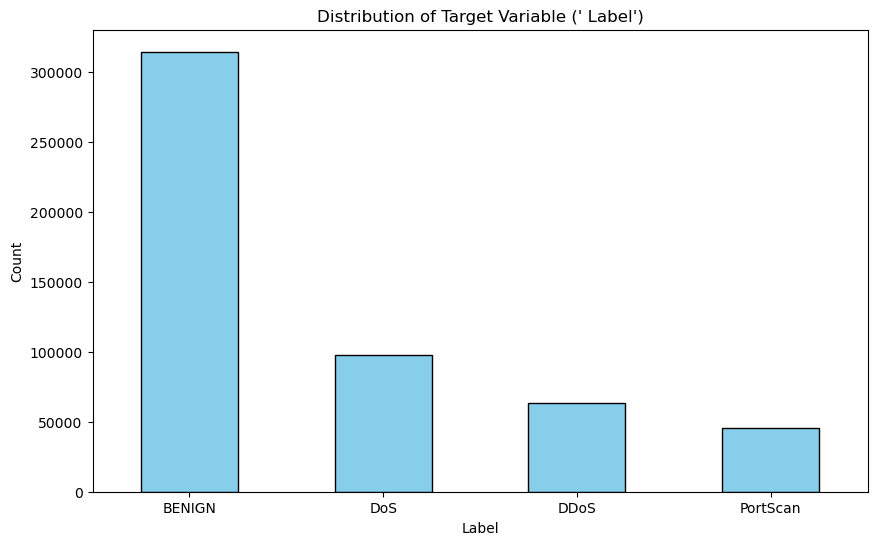

In [5]:
plt.figure(figsize=(10, 6))
data[' Label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Target Variable (' Label')")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [6]:
X = data.drop(columns=[' Label'])
y = data[' Label']

In [7]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=20)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9992998004910988
Classification Report:
               precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     62900
        DDoS       1.00      1.00      1.00     12725
         DoS       1.00      1.00      1.00     19491
    PortScan       1.00      1.00      1.00      9140

    accuracy                           1.00    104256
   macro avg       1.00      1.00      1.00    104256
weighted avg       1.00      1.00      1.00    104256



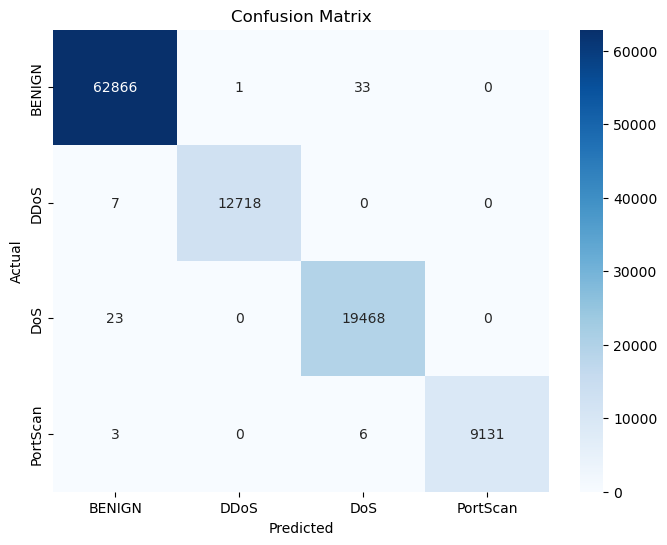

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

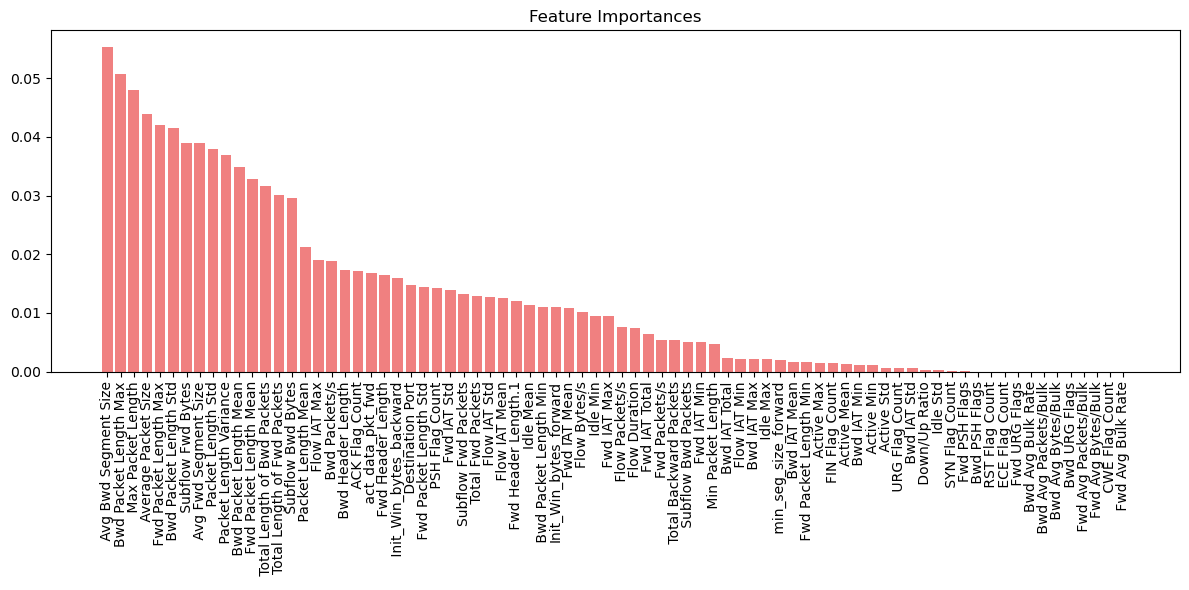

<Figure size 640x480 with 0 Axes>

Feature importance visualization saved as C:\Users\aadil\Downloads\feature_importance.png


In [27]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.drop(columns=[' Label']).columns

plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], color="lightcoral", align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()
feature_importance_path = r'C:\Users\aadil\Downloads\feature_importance.png'
plt.savefig(feature_importance_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Feature importance visualization saved as {feature_importance_path}")

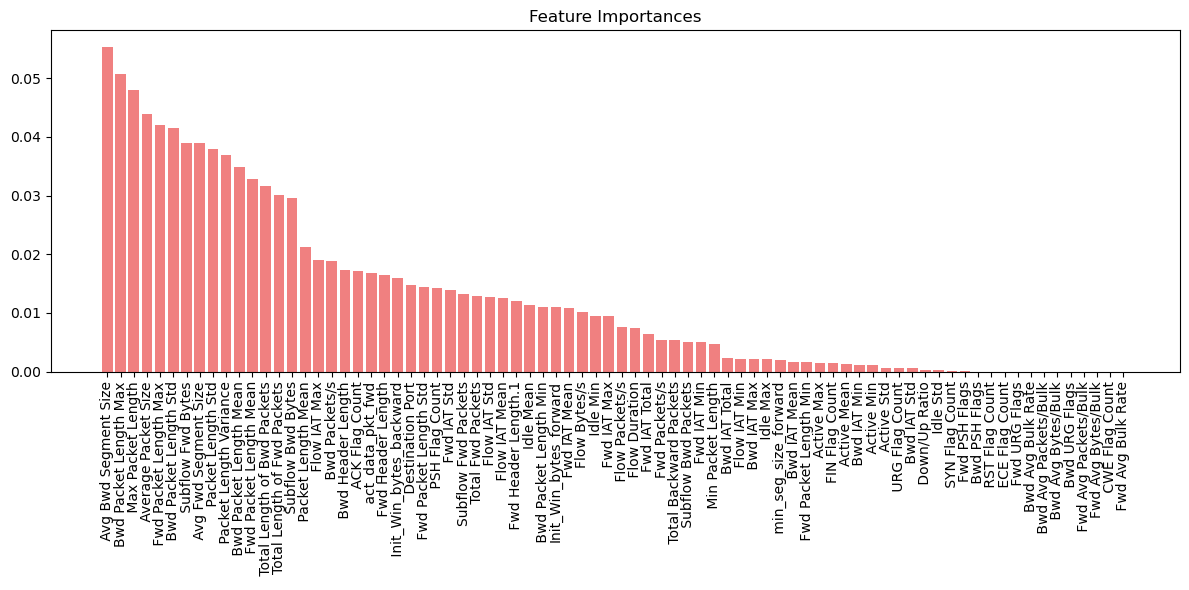

Feature importance visualization saved as C:\Users\aadil\Downloads\feature_importance.png


In [29]:

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.drop(columns=[' Label']).columns

# Create the plot
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], color="lightcoral", align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.tight_layout()

# Save the plot BEFORE showing it
feature_importance_path = r'C:\Users\aadil\Downloads\feature_importance.png'
plt.savefig(feature_importance_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Feature importance visualization saved as {feature_importance_path}")
